In [41]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from scipy.linalg import cholesky, qr
from arch.univariate import ZeroMean, GARCH, EGARCH, StudentsT, SkewStudent
from scipy.optimize import minimize
from statsmodels.stats.diagnostic import het_arch

In [6]:
# ==============================================================================
# DATA: Загрузка и расчет лог-доходностей
# ==============================================================================
tickers = ['NVDA', 'AMD', 'INTC', 'SOXX']
data = yf.download(tickers, start="2001-07-09", interval="1wk")['Close']

# Расчет недельных лог-доходностей (аналог diff(log(x)))
returns = np.log(data / data.shift(1)).dropna()

# Сплит по дате структурного сдвига
break_date = "2015-07-27"
df_pre = returns[:break_date].copy()
df_post = returns[break_date:].copy()


[*********************100%***********************]  4 of 4 completed


In [38]:
# ==============================================================================
# BLOCK 1: VAR MODEL
# ==============================================================================
def fit_var(df, name):
    model = VAR(df)
    order = model.select_order(maxlags=15)
    print(f"\n--- Lag Selection ({name}) ---\n", order.summary())
    
    results = model.fit(1)
    print(f"\n--- VAR(1) Summary ({name}) ---\n", results.summary())

    out = results.test_whiteness(nlags=2)
    print(f"\nWhiteness test (p-value): {out.pvalue:.4f}")
    
    return results

res_pre = fit_var(df_pre, "Before 2015")
res_post = fit_var(df_post, "After 2015")


--- Lag Selection (Before 2015) ---
  VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -25.02     -24.99*   1.367e-11     -25.01*
1      -25.03*      -24.90  1.353e-11*      -24.98
2       -25.01      -24.78   1.376e-11      -24.92
3       -25.01      -24.68   1.370e-11      -24.89
4       -25.01      -24.58   1.377e-11      -24.84
5       -24.99      -24.45   1.407e-11      -24.78
6       -24.98      -24.34   1.416e-11      -24.73
7       -24.96      -24.23   1.439e-11      -24.68
8       -24.94      -24.10   1.479e-11      -24.61
9       -24.93      -23.99   1.489e-11      -24.57
10      -24.91      -23.86   1.523e-11      -24.50
11      -24.90      -23.75   1.541e-11      -24.45
12      -24.87      -23.62   1.576e-11      -24.39
13      -24.85      -23.50   1.617e-11      -24.33
14      -24.83      -23.38   1.646e-11      -24.27
15      -24.81      -23.26   1.680e-11      

C:\Users\kweec\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\kweec\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


In [36]:
# ==============================================================================
# BLOCK 2: GRANGER CAUSALITY
# ==============================================================================
def check_granger(results, name):
    print(f"\n=== Granger Causality: {name} ===")
    for target in tickers:
        other_vars = [v for v in tickers if v != target]
        try:
            test_res = results.test_causality(target, other_vars, kind='f')
            print(f"{', '.join(other_vars)} -> {target}: p-value = {test_res.pvalue:.4f}")
        except:
            pass

check_granger(res_pre, "Pre-2015")
check_granger(res_post, "Post-2015")


=== Granger Causality: Pre-2015 ===
AMD, INTC, SOXX -> NVDA: p-value = 0.4535
NVDA, INTC, SOXX -> AMD: p-value = 0.0637
NVDA, AMD, SOXX -> INTC: p-value = 0.1711
NVDA, AMD, INTC -> SOXX: p-value = 0.0880

=== Granger Causality: Post-2015 ===
AMD, INTC, SOXX -> NVDA: p-value = 0.0516
NVDA, INTC, SOXX -> AMD: p-value = 0.1670
NVDA, AMD, SOXX -> INTC: p-value = 0.6666
NVDA, AMD, INTC -> SOXX: p-value = 0.2798


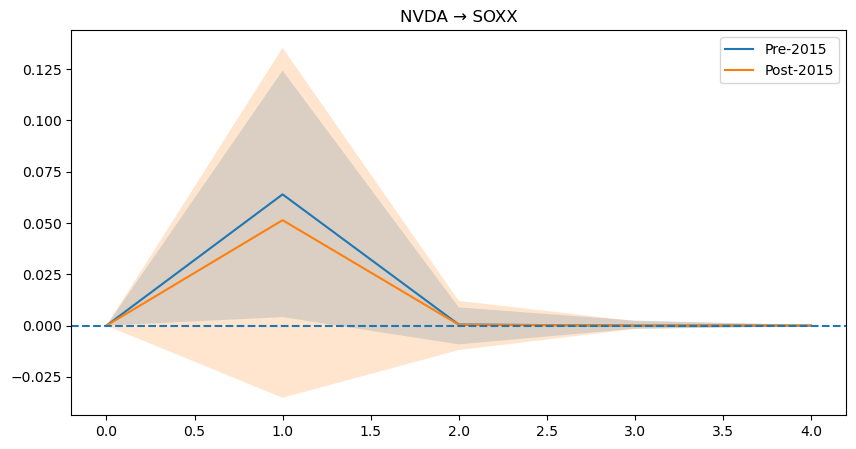

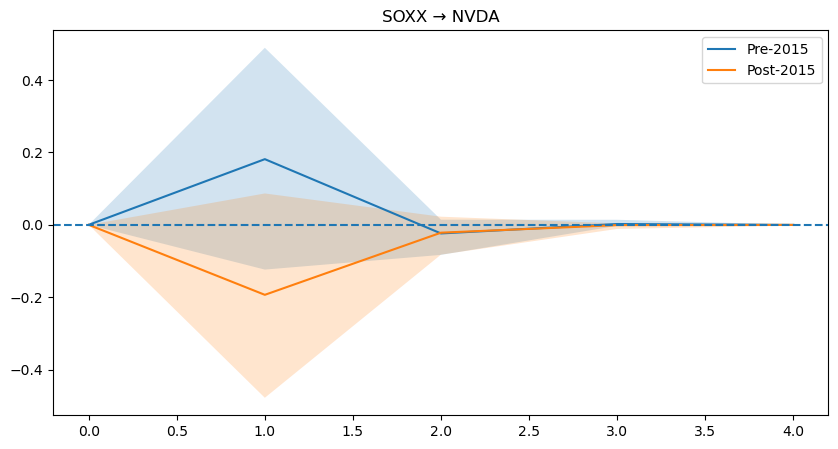

In [26]:
# ==============================================================================
# BLOCK 3: IMPULSE RESPONSE FUNCTIONS (IRF)
# ==============================================================================
def plot_comparison_irf(res_pre, res_post, impulse, response, steps=12):
    irf_pre = res_pre.irf(steps)
    irf_post = res_post.irf(steps)

    idx_imp = res_pre.names.index(impulse)
    idx_res = res_pre.names.index(response)

    y_pre = irf_pre.irfs[:, idx_res, idx_imp]
    y_post = irf_post.irfs[:, idx_res, idx_imp]

    # bootstrap CI
    lower_pre, upper_pre = irf_pre.errband_mc(orth = False, repl=500)
    lower_post, upper_post = irf_post.errband_mc(orth = False, repl=500)

    lower_pre = lower_pre[:, idx_res, idx_imp]
    upper_pre = upper_pre[:, idx_res, idx_imp]

    lower_post = lower_post[:, idx_res, idx_imp]
    upper_post = upper_post[:, idx_res, idx_imp]

    h = np.arange(steps + 1)

    plt.figure(figsize=(10,5))
    plt.plot(h, y_pre, label="Pre-2015")
    plt.fill_between(h, lower_pre, upper_pre, alpha=0.2)

    plt.plot(h, y_post, label="Post-2015")
    plt.fill_between(h, lower_post, upper_post, alpha=0.2)

    plt.axhline(0, linestyle="--")
    plt.legend()
    plt.title(f"{impulse} → {response}")
    plt.show()

# Запуск
plot_comparison_irf(res_pre, res_post, 'NVDA', 'SOXX',4)
plot_comparison_irf(res_pre, res_post, 'SOXX', 'NVDA',4)


In [31]:
def sign_restrictions_svar(var_results, sign_mat, n_draws=10000, n_ahead=5):
    sigma = var_results.sigma_u
    p = cholesky(sigma, lower=True)
    n = sigma.shape[0]

    a_coefs = var_results.coefs[0]

    accepted_irfs = []

    for _ in range(n_draws):

        z = np.random.normal(size=(n, n))
        q, r = qr(z)

        q = q @ np.diag(np.sign(np.diag(r)))

        b_cand = p @ q
        signs = np.sign(np.diag(b_cand))
        signs[signs == 0] = 1
        q = q @ np.diag(signs)
        b_cand = p @ q

        # sign restrictions
        match = True
        for r_idx in range(n):
            for c_idx in range(n):
                restriction = sign_mat[r_idx, c_idx]
                if not np.isnan(restriction):
                    if np.sign(b_cand[r_idx, c_idx]) != np.sign(restriction):
                        match = False
                        break
            if not match:
                break

        if match:
            irf_draw = np.zeros((n, n, n_ahead + 1))
            irf_draw[:, :, 0] = b_cand

            phi = np.eye(n)

            for h in range(1, n_ahead + 1):
                phi = a_coefs @ phi
                irf_draw[:, :, h] = phi @ b_cand

            accepted_irfs.append(irf_draw)

    if len(accepted_irfs) == 0:
        raise ValueError("No rotations accepted — relax sign restrictions")

    accepted_irfs = np.array(accepted_irfs)

    return {
        'mean': np.mean(accepted_irfs, axis=0),
        'lower': np.percentile(accepted_irfs, 16, axis=0),
        'upper': np.percentile(accepted_irfs, 84, axis=0),
        'n_accept': len(accepted_irfs),
        'n_draws': n_draws
    }

nan = np.nan
sign_mat = np.array([
    [ 1, nan, nan,  1], # NVDA
    [ 1,  1,  nan,  1], # AMD
    [nan, nan,  1,  1], # INTC
    [nan, nan, nan,  1]  # SOXX
])

svar_pre = sign_restrictions_svar(res_pre, sign_mat, n_draws=10000)
svar_post = sign_restrictions_svar(res_post, sign_mat, n_draws=10000)

print(f"Rotations accepted (Pre): {svar_pre['n_accept']}")
print(f"Rotation accepted (Post): {svar_post['n_accept']}")

def fevd_sign(svar_result):
    irf_mean = svar_result['mean']  # (n, n, steps)
    n, _, steps = irf_mean.shape
    
    fevd = np.zeros((n, n, steps))
    
    for i in range(n):
        mse_total = np.zeros(steps)
        for h in range(steps):

            shock_contribs = np.sum(irf_mean[i, :, :h+1]**2, axis=1)
            mse_total[h] = np.sum(shock_contribs)
            fevd[i, :, h] = shock_contribs / mse_total[h]
            
    return fevd

fevd_pre = fevd_sign(svar_pre)
fevd_post = fevd_sign(svar_post)

print(f"NVDA's share in SOXX's variance (Pre): {fevd_pre[3, 0, 0]:.3f}")
print(f"NVDA's share is SOXX's variance (Post): {fevd_post[3, 0, 0]:.3f}")

Принято ротаций (Pre): 2996
Принято ротаций (Post): 2218
Доля шока NVDA в дисперсии SOXX (Pre): 0.280
Доля шока NVDA в дисперсии SOXX (Post): 0.233


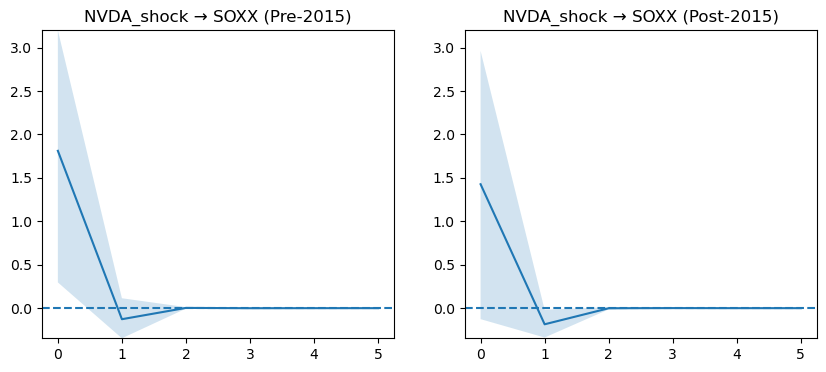

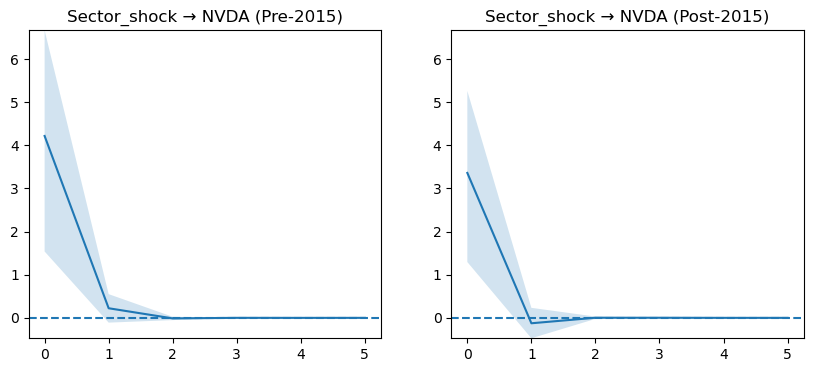

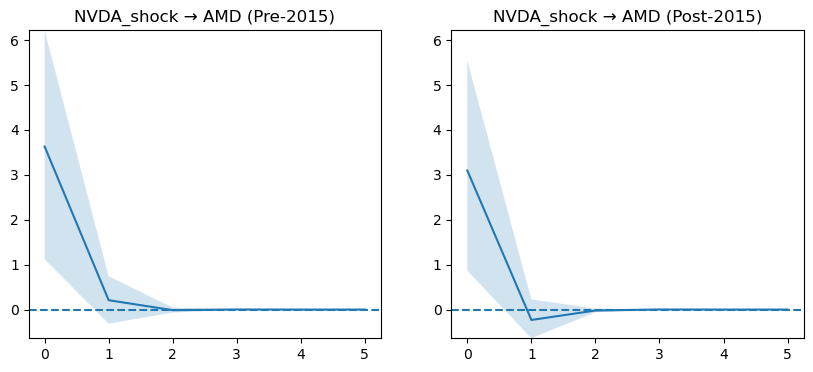

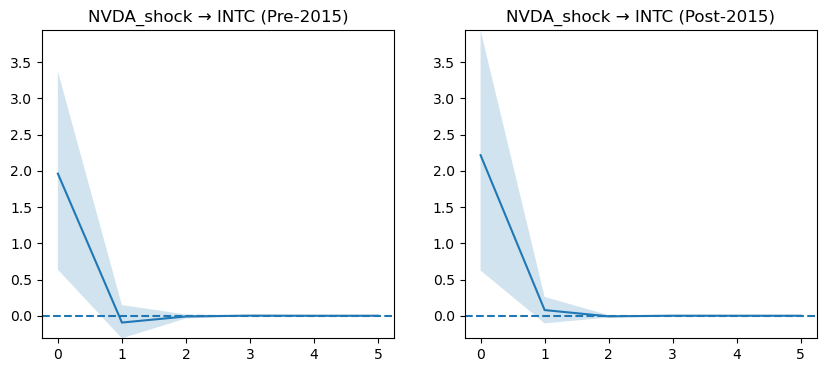

In [34]:
def plot_sign_irf(svar_pre, svar_post, impulse, response, n_ahead=5, scale=100):

    shock_idx = shock_names.index(impulse)
    resp_idx = var_names.index(response)

    h = np.arange(n_ahead + 1)

    pre_irf = svar_pre['mean'][resp_idx, shock_idx, :] * scale
    pre_lo  = svar_pre['lower'][resp_idx, shock_idx, :] * scale
    pre_hi  = svar_pre['upper'][resp_idx, shock_idx, :] * scale

    post_irf = svar_post['mean'][resp_idx, shock_idx, :] * scale
    post_lo  = svar_post['lower'][resp_idx, shock_idx, :] * scale
    post_hi  = svar_post['upper'][resp_idx, shock_idx, :] * scale

    ylim = (
        min(pre_lo.min(), post_lo.min()),
        max(pre_hi.max(), post_hi.max())
    )

    fig, axes = plt.subplots(1, 2, figsize=(10,4))

    # PRE
    axes[0].plot(h, pre_irf)
    axes[0].fill_between(h, pre_lo, pre_hi, alpha=0.2)
    axes[0].axhline(0, linestyle="--")
    axes[0].set_title(f"{impulse} → {response} (Pre-2015)")
    axes[0].set_ylim(ylim)

    # POST
    axes[1].plot(h, post_irf)
    axes[1].fill_between(h, post_lo, post_hi, alpha=0.2)
    axes[1].axhline(0, linestyle="--")
    axes[1].set_title(f"{impulse} → {response} (Post-2015)")
    axes[1].set_ylim(ylim)

    plt.show()

plot_sign_irf(svar_pre, svar_post, "NVDA_shock",   "SOXX")
plot_sign_irf(svar_pre, svar_post, "Sector_shock", "NVDA")
plot_sign_irf(svar_pre, svar_post, "NVDA_shock",   "AMD")
plot_sign_irf(svar_pre, svar_post, "NVDA_shock",   "INTC")

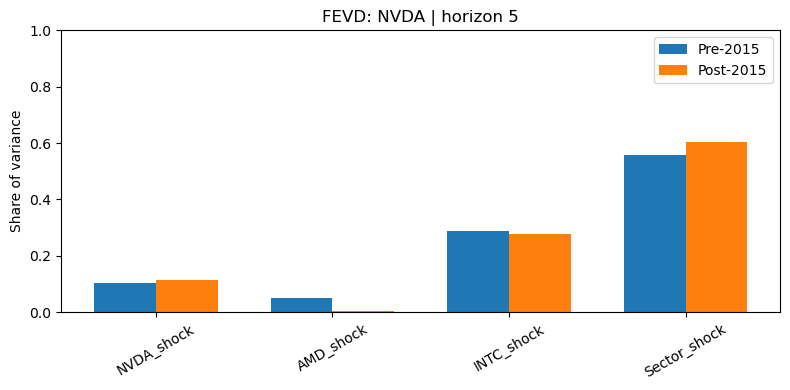

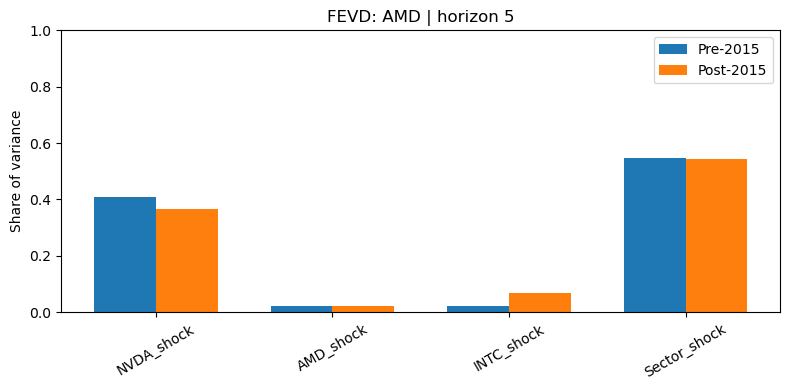

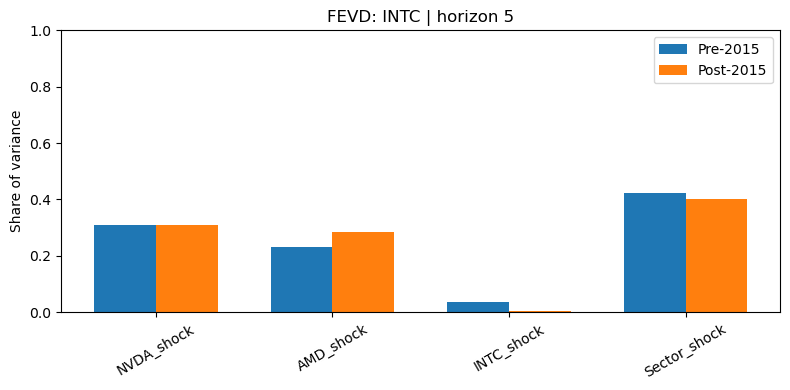

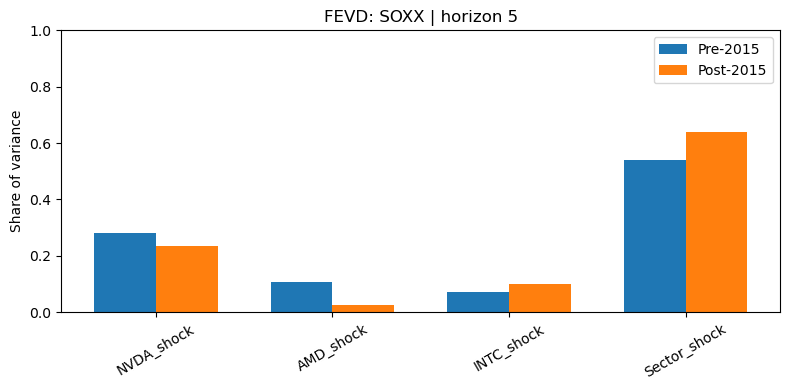

In [35]:
def plot_fevd_comparison(fevd_pre, fevd_post, variable, horizon=5):
    
    var_idx = var_names.index(variable)

    pre = fevd_pre[var_idx, :, horizon]
    post = fevd_post[var_idx, :, horizon]

    x = np.arange(len(shock_names))
    width = 0.35

    plt.figure(figsize=(8, 4))

    plt.bar(x - width/2, pre, width, label="Pre-2015")
    plt.bar(x + width/2, post, width, label="Post-2015")

    plt.xticks(x, shock_names, rotation=30)
    plt.ylim(0, 1)

    plt.title(f"FEVD: {variable} | horizon {horizon}")
    plt.ylabel("Share of variance")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_fevd_comparison(fevd_pre, fevd_post, "NVDA")
plot_fevd_comparison(fevd_pre, fevd_post, "AMD")
plot_fevd_comparison(fevd_pre, fevd_post, "INTC")
plot_fevd_comparison(fevd_pre, fevd_post, "SOXX")

In [42]:
# ===== STEP 1: ARCH-LM test =====

print("\n===== ARCH-LM test (pre) =====")
resid_pre = res_pre.resid
for col in resid_pre.columns:
    stat, pval, _, _ = het_arch(resid_pre[col].dropna(), nlags=5)
    print(f"{col}: Chi2={stat:.3f}, p={pval:.4f}")

print("\n===== ARCH-LM test (post) =====")
resid_post = res_post.resid
for col in resid_post.columns:
    stat, pval, _, _ = het_arch(resid_post[col].dropna(), nlags=5)
    print(f"{col}: Chi2={stat:.3f}, p={pval:.4f}")


# ===== STEP 2: Univariate GARCH fits =====
def fit_garch(series, model_type="sGARCH", mean=True):
    y = series.dropna() * 100

    if model_type == "gjr":
        am = ZeroMean(y) if not mean else ZeroMean(y)
        am.volatility = GARCH(p=1, o=1, q=1)
    else:
        am = ZeroMean(y) if not mean else ZeroMean(y)
        am.volatility = GARCH(p=1, q=1)

    am.distribution = SkewStudent()
    res = am.fit(disp="off")
    return res

garch_pre = {
    "NVDA": fit_garch(df_pre["NVDA"], "gjr", mean=False),
    "AMD":  fit_garch(df_pre["AMD"],  "sGARCH", mean=False),
    "INTC": fit_garch(df_pre["INTC"], "sGARCH", mean=False),
    "SOXX": fit_garch(df_pre["SOXX"], "sGARCH", mean=False)
}

garch_post = {
    "NVDA": fit_garch(df_post["NVDA"], "gjr", mean=True),
    "AMD":  fit_garch(df_post["AMD"],  "sGARCH", mean=True),
    "INTC": fit_garch(df_post["INTC"], "sGARCH", mean=False),
    "SOXX": fit_garch(df_post["SOXX"], "sGARCH", mean=True)
}


# ===== STEP 3: Extract standardized residuals =====
def get_std_resids(fits):
    z = []
    sigmas = []
    for k in ["NVDA","AMD","INTC","SOXX"]:
        res = fits[k]
        z.append(res.resid / res.conditional_volatility)
        sigmas.append(res.conditional_volatility)
    return np.column_stack(z), np.column_stack(sigmas)

z_pre, sigma_pre = get_std_resids(garch_pre)
z_post, sigma_post = get_std_resids(garch_post)


# ===== STEP 4: DCC likelihood =====
def dcc_loglik(params, z):
    a, b = params
    T, n = z.shape

    Qbar = np.cov(z.T)
    Qt = Qbar.copy()

    ll = 0
    for t in range(T):
        if t > 0:
            Qt = (1 - a - b) * Qbar + a * np.outer(z[t-1], z[t-1]) + b * Qt

        D = np.diag(1 / np.sqrt(np.diag(Qt)))
        Rt = D @ Qt @ D

        ll += np.log(np.linalg.det(Rt)) + z[t] @ np.linalg.inv(Rt) @ z[t]

    return ll


def fit_dcc(z):
    bounds = [(1e-6, 0.999), (1e-6, 0.999)]
    cons = ({'type': 'ineq', 'fun': lambda x: 1 - x[0] - x[1]})

    res = minimize(dcc_loglik, x0=[0.05, 0.9], args=(z,),
                   bounds=bounds, constraints=cons)

    return res.x


a_pre, b_pre = fit_dcc(z_pre)
a_post, b_post = fit_dcc(z_post)



===== ARCH-LM test (pre) =====
AMD: Chi2=40.420, p=0.0000
INTC: Chi2=37.970, p=0.0000
NVDA: Chi2=26.743, p=0.0001
SOXX: Chi2=79.612, p=0.0000

===== ARCH-LM test (post) =====
AMD: Chi2=2.778, p=0.7341
INTC: Chi2=13.283, p=0.0209
NVDA: Chi2=14.909, p=0.0108
SOXX: Chi2=41.330, p=0.0000


C:\Users\kweec\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)



===== Mean correlations (pre) =====
             mean     min     max
pair                             
AMD-INTC   0.4865  0.2854  0.6082
AMD-SOXX   0.6636  0.5508  0.7563
INTC-SOXX  0.7530  0.6176  0.8243
NVDA-AMD   0.4773  0.4020  0.5579
NVDA-INTC  0.5051  0.3384  0.6212
NVDA-SOXX  0.7029  0.6214  0.7684

===== Mean correlations (post) =====
             mean     min     max
pair                             
AMD-INTC   0.2908 -0.0663  0.5194
AMD-SOXX   0.6529  0.3599  0.7829
INTC-SOXX  0.5928  0.4007  0.7292
NVDA-AMD   0.5601  0.3301  0.7107
NVDA-INTC  0.3699  0.1450  0.5555
NVDA-SOXX  0.7531  0.5873  0.8347

===== Change =====
           mean_pre  mean_post   delta
pair                                  
AMD-INTC     0.4865     0.2908 -0.1957
AMD-SOXX     0.6636     0.6529 -0.0107
INTC-SOXX    0.7530     0.5928 -0.1602
NVDA-AMD     0.4773     0.5601  0.0828
NVDA-INTC    0.5051     0.3699 -0.1352
NVDA-SOXX    0.7029     0.7531  0.0502


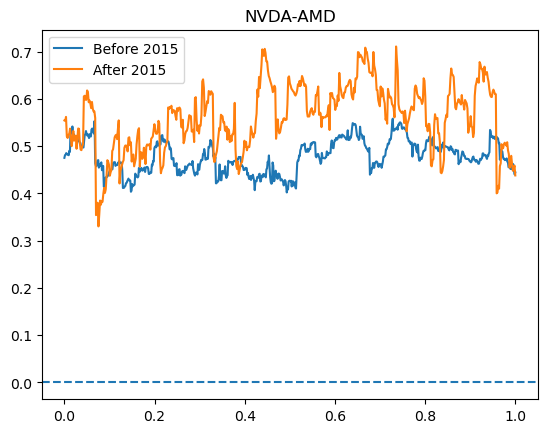

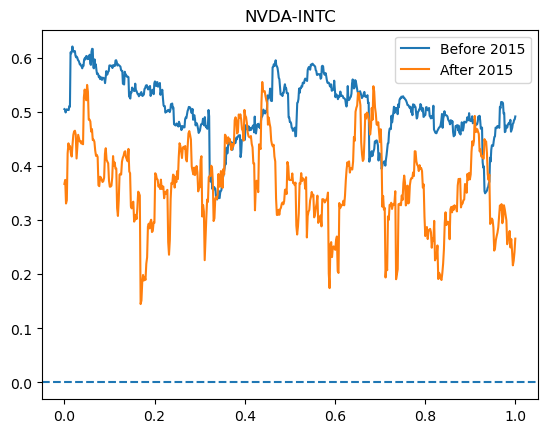

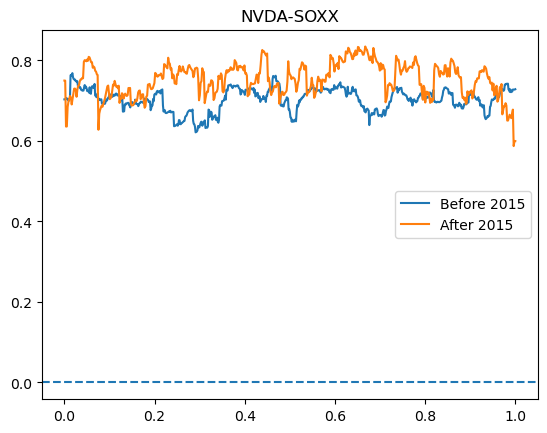

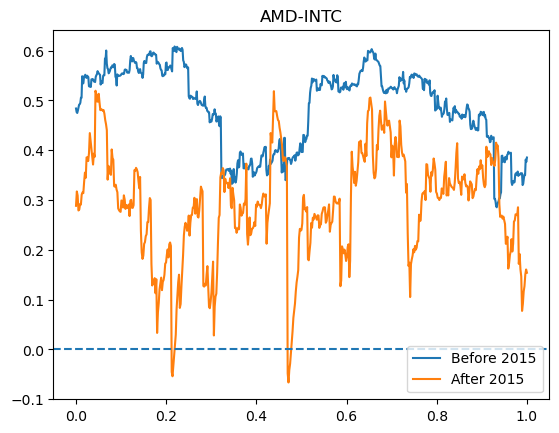

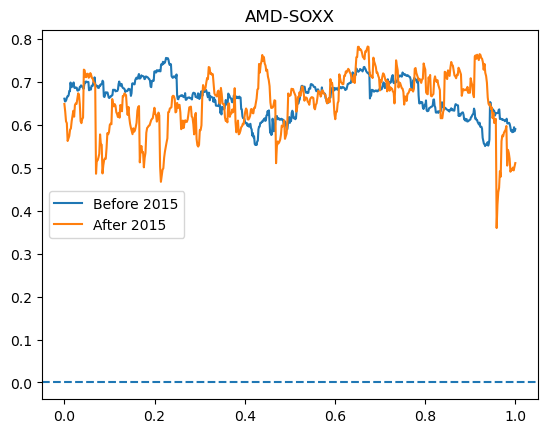

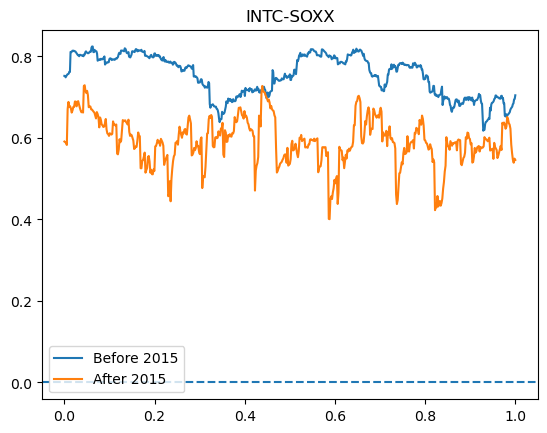

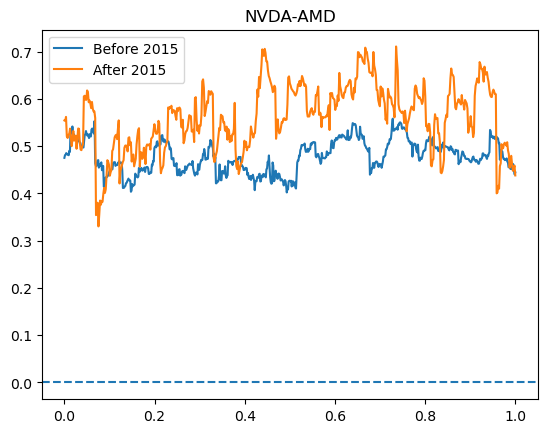

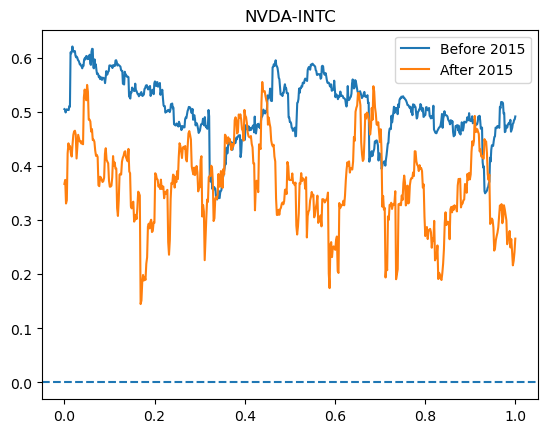

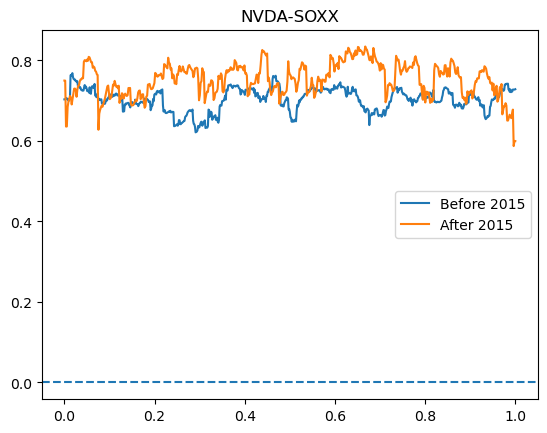

<Figure size 640x480 with 0 Axes>

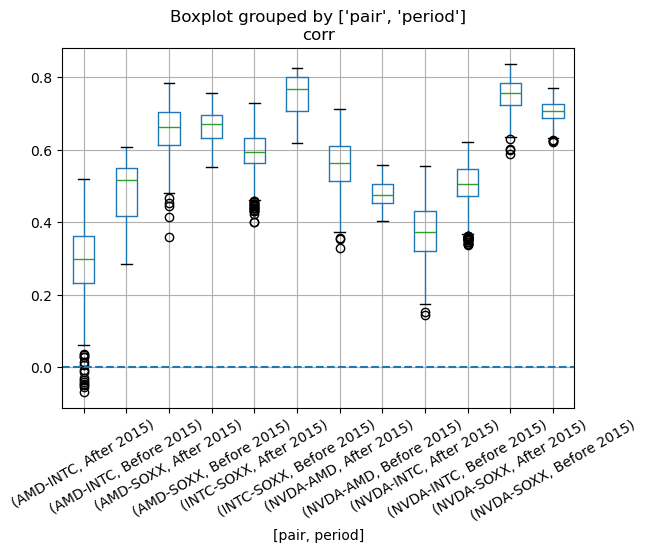


===== DCC parameters =====
Pre: 0.01396822900686686 0.9714479946468799 Persistence: 0.9854162236537468
Post: 0.03882699638902149 0.8932805958705133 Persistence: 0.9321075922595349


In [43]:
# ===== STEP 5: Compute dynamic correlations =====
def compute_dcc_corr(z, a, b):
    T, n = z.shape
    Qbar = np.cov(z.T)
    Qt = Qbar.copy()

    Rts = np.zeros((T, n, n))

    for t in range(T):
        if t > 0:
            Qt = (1 - a - b) * Qbar + a * np.outer(z[t-1], z[t-1]) + b * Qt

        D = np.diag(1 / np.sqrt(np.diag(Qt)))
        Rt = D @ Qt @ D
        Rts[t] = Rt

    return Rts

R_pre = compute_dcc_corr(z_pre, a_pre, b_pre)
R_post = compute_dcc_corr(z_post, a_post, b_post)


# ===== STEP 6: Extract pairwise correlations =====
pairs = [(1,0),(2,0),(3,0),(2,1),(3,1),(3,2)]
pair_names = ["NVDA-AMD","NVDA-INTC","NVDA-SOXX","AMD-INTC","AMD-SOXX","INTC-SOXX"]

def extract_corr(R, label):
    T = R.shape[0]
    rows = []
    for k,(i,j) in enumerate(pairs):
        for t in range(T):
            rows.append([t, R[t,i,j], pair_names[k], label])
    return pd.DataFrame(rows, columns=["t","corr","pair","period"])

corr_pre = extract_corr(R_pre, "Before 2015")
corr_post = extract_corr(R_post, "After 2015")


# ===== STEP 7: Summary tables =====
tbl_pre = corr_pre.groupby("pair")["corr"].agg(["mean","min","max"]).round(4)
tbl_post = corr_post.groupby("pair")["corr"].agg(["mean","min","max"]).round(4)

print("\n===== Mean correlations (pre) =====")
print(tbl_pre)

print("\n===== Mean correlations (post) =====")
print(tbl_post)

tbl_diff = tbl_pre.join(tbl_post, lsuffix="_pre", rsuffix="_post")
tbl_diff["delta"] = (tbl_diff["mean_post"] - tbl_diff["mean_pre"]).round(4)

print("\n===== Change =====")
print(tbl_diff[["mean_pre","mean_post","delta"]])


# ===== STEP 8: Plots =====
corr_all = pd.concat([corr_pre, corr_post])
corr_all["t_norm"] = corr_all.groupby(["pair","period"])["t"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

# 8a
for p in corr_all["pair"].unique():
    sub = corr_all[corr_all["pair"]==p]
    plt.figure()
    for label in ["Before 2015","After 2015"]:
        s = sub[sub["period"]==label]
        plt.plot(s["t_norm"], s["corr"], label=label)
    plt.axhline(0, linestyle="--")
    plt.title(p)
    plt.legend()
    plt.show()

# 8b NVDA only
nvda_pairs = [p for p in pair_names if "NVDA" in p]
for p in nvda_pairs:
    sub = corr_all[corr_all["pair"]==p]
    plt.figure()
    for label in ["Before 2015","After 2015"]:
        s = sub[sub["period"]==label]
        plt.plot(s["t_norm"], s["corr"], label=label)
    plt.axhline(0, linestyle="--")
    plt.title(p)
    plt.legend()
    plt.show()

# 8c boxplot
plt.figure()
corr_all.boxplot(column="corr", by=["pair","period"], rot=30)
plt.axhline(0, linestyle="--")
plt.show()


# ===== STEP 9: Parameters =====
print("\n===== DCC parameters =====")
print("Pre:", a_pre, b_pre, "Persistence:", a_pre + b_pre)
print("Post:", a_post, b_post, "Persistence:", a_post + b_post)

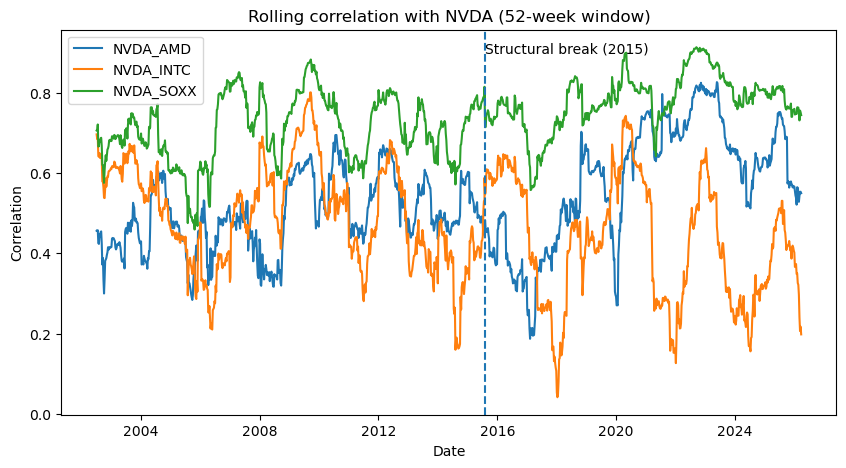

In [44]:
# ==============================
# BLOCK 6: ROLLING CORRELATION
# ==============================

window = 52

nvda_full = pd.concat([df_pre["NVDA"], df_post["NVDA"]])
amd_full  = pd.concat([df_pre["AMD"],  df_post["AMD"]])
intc_full = pd.concat([df_pre["INTC"], df_post["INTC"]])
soxx_full = pd.concat([df_pre["SOXX"], df_post["SOXX"]])

roll_nvda_amd  = nvda_full.rolling(window).corr(amd_full)
roll_nvda_intc = nvda_full.rolling(window).corr(intc_full)
roll_nvda_soxx = nvda_full.rolling(window).corr(soxx_full)

df_roll = pd.DataFrame({
    "date": nvda_full.index,
    "NVDA_AMD": roll_nvda_amd.values,
    "NVDA_INTC": roll_nvda_intc.values,
    "NVDA_SOXX": roll_nvda_soxx.values
}).dropna()

df_long = df_roll.melt(id_vars="date", var_name="pair", value_name="correlation")

plt.figure(figsize=(10,5))
for p in df_long["pair"].unique():
    sub = df_long[df_long["pair"] == p]
    plt.plot(sub["date"], sub["correlation"], label=p)

plt.axvline(pd.to_datetime("2015-07-27"), linestyle="--")
plt.text(pd.to_datetime("2015-07-27"), 0.9, "Structural break (2015)")

plt.title("Rolling correlation with NVDA (52-week window)")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()
plt.show()

In [45]:
# ==============================
# BLOCK 7: DCC-GARCH DIAGNOSTICS
# ==============================

from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

series_names = ["NVDA","AMD","INTC","SOXX"]

def run_diagnostics(z, label):
    print("\n" + "="*60)
    print("Diagnostics:", label)
    print("="*60)

    for i, s in enumerate(series_names):
        zi = z[:, i]

        print(f"\n--- {s} ---")

        # ARCH-LM
        stat, pval, _, _ = het_arch(zi, nlags=5)
        print(f"ARCH-LM(5):      Chi2={stat:.3f}, p={pval:.4f}")

        # Ljung-Box
        lb = acorr_ljungbox(zi, lags=[10], return_df=True)
        print(f"Ljung-Box(10):   Chi2={lb['lb_stat'].iloc[0]:.3f}, p={lb['lb_pvalue'].iloc[0]:.4f}")

        # Ljung-Box squared
        lb2 = acorr_ljungbox(zi**2, lags=[10], return_df=True)
        print(f"Ljung-Box^2(10): Chi2={lb2['lb_stat'].iloc[0]:.3f}, p={lb2['lb_pvalue'].iloc[0]:.4f}")

        # Jarque-Bera
        jb_stat, jb_p = jarque_bera(zi)
        print(f"Jarque-Bera:     Chi2={jb_stat:.3f}, p={jb_p:.4f}")

    print("\n--- DCC cross-residual Ljung-Box (zi * zj, lag=10) ---")

    pairs_diag = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]

    for i, j in pairs_diag:
        prod = z[:, i] * z[:, j]
        lb = acorr_ljungbox(prod, lags=[10], return_df=True)
        print(f"{series_names[i]} x {series_names[j]}: "
              f"Chi2={lb['lb_stat'].iloc[0]:.3f}, p={lb['lb_pvalue'].iloc[0]:.4f}")


run_diagnostics(z_pre, "Pre-2015")
run_diagnostics(z_post, "Post-2015")


Diagnostics: Pre-2015

--- NVDA ---
ARCH-LM(5):      Chi2=0.830, p=0.9751
Ljung-Box(10):   Chi2=8.519, p=0.5783
Ljung-Box^2(10): Chi2=1.518, p=0.9989
Jarque-Bera:     Chi2=656.353, p=0.0000

--- AMD ---
ARCH-LM(5):      Chi2=1.628, p=0.8978
Ljung-Box(10):   Chi2=12.754, p=0.2377
Ljung-Box^2(10): Chi2=6.321, p=0.7876
Jarque-Bera:     Chi2=141.989, p=0.0000

--- INTC ---
ARCH-LM(5):      Chi2=8.921, p=0.1123
Ljung-Box(10):   Chi2=3.137, p=0.9780
Ljung-Box^2(10): Chi2=10.450, p=0.4019
Jarque-Bera:     Chi2=160.480, p=0.0000

--- SOXX ---
ARCH-LM(5):      Chi2=0.507, p=0.9919
Ljung-Box(10):   Chi2=4.825, p=0.9025
Ljung-Box^2(10): Chi2=1.319, p=0.9994
Jarque-Bera:     Chi2=34.167, p=0.0000

--- DCC cross-residual Ljung-Box (zi * zj, lag=10) ---
NVDA x AMD: Chi2=7.072, p=0.7186
NVDA x INTC: Chi2=7.956, p=0.6332
NVDA x SOXX: Chi2=1.934, p=0.9968
AMD x INTC: Chi2=10.690, p=0.3821
AMD x SOXX: Chi2=2.904, p=0.9836
INTC x SOXX: Chi2=9.619, p=0.4745

Diagnostics: Post-2015

--- NVDA ---
ARCH-LM(5


===== Volatility forecast (weekly sigma) =====
[[6.156911 7.04097  6.960996 3.901668]
 [6.368044 7.040609 6.968257 3.956919]
 [6.543073 7.04025  6.975479 4.006956]
 [6.689017 7.039894 6.982663 4.052334]
 [6.811257 7.03954  6.98981  4.093538]
 [6.914005 7.039189 6.996918 4.130992]
 [7.000615 7.038841 7.00399  4.165068]
 [7.073787 7.038495 7.011024 4.196099]
 [7.135723 7.038152 7.018021 4.224378]
 [7.188227 7.037811 7.024982 4.250165]
 [7.232793 7.037473 7.031906 4.273694]
 [7.270661 7.037137 7.038794 4.295176]]

===== Annualized volatility =====
[[44.3981 50.7732 50.1965 28.1353]
 [45.9206 50.7706 50.2488 28.5337]
 [47.1828 50.768  50.3009 28.8946]
 [48.2352 50.7654 50.3527 29.2218]
 [49.1167 50.7628 50.4042 29.5189]
 [49.8576 50.7603 50.4555 29.789 ]
 [50.4822 50.7578 50.5065 30.0347]
 [51.0098 50.7553 50.5572 30.2585]
 [51.4564 50.7528 50.6077 30.4624]
 [51.835  50.7504 50.6579 30.6484]
 [52.1564 50.7479 50.7078 30.818 ]
 [52.4295 50.7455 50.7575 30.973 ]]


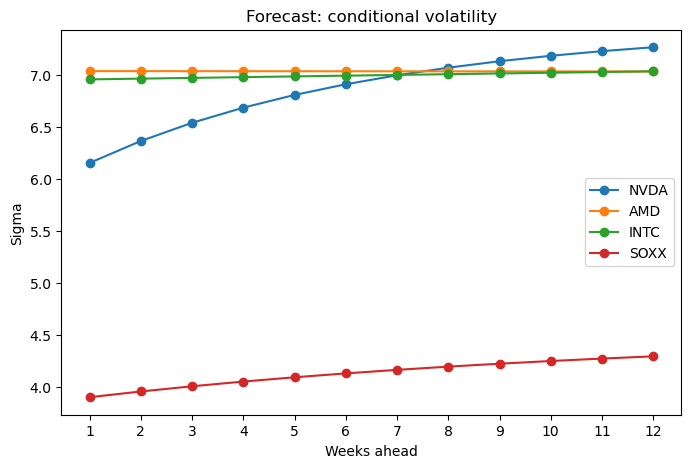


===== Correlation forecast =====
               h1      h6     h12
pair                             
AMD-INTC   0.1636  0.2019  0.2323
AMD-SOXX   0.5205  0.5583  0.5893
INTC-SOXX  0.5490  0.5616  0.5718
NVDA-AMD   0.4465  0.4803  0.5067
NVDA-INTC  0.2740  0.3047  0.3276
NVDA-SOXX  0.6106  0.6538  0.6878


C:\Users\kweec\AppData\Local\Temp\ipykernel_13156\3834318030.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


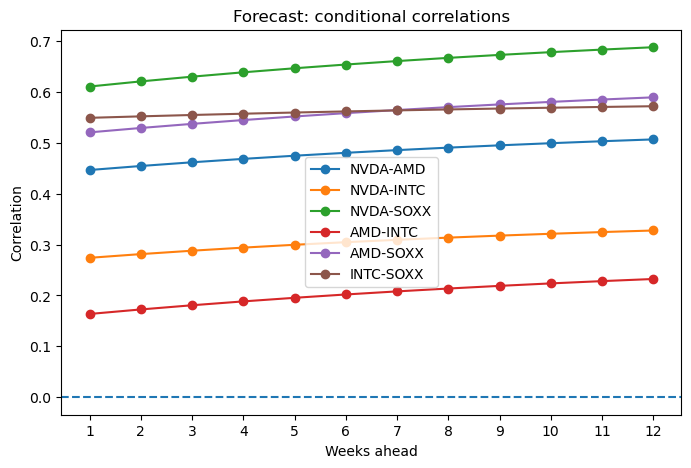

In [46]:
# ==============================
# BLOCK 8: DCC-GARCH FORECAST
# ==============================

n_ahead = 12
T = z_post.shape[0]
n = z_post.shape[1]

# ===== STEP 1: Forecast Q_t and R_t =====
def dcc_forecast(z, a, b, n_ahead):
    Qbar = np.cov(z.T)
    Qt = Qbar.copy()

    # прогон до последнего наблюдения
    for t in range(1, len(z)):
        Qt = (1 - a - b) * Qbar + a * np.outer(z[t-1], z[t-1]) + b * Qt

    forecasts = []

    for h in range(n_ahead):
        Qt = (1 - a - b) * Qbar + (a + b) * Qt
        D = np.diag(1 / np.sqrt(np.diag(Qt)))
        Rt = D @ Qt @ D
        forecasts.append(Rt)

    return np.array(forecasts)  # (horizon, n, n)

R_fc = dcc_forecast(z_post, a_post, b_post, n_ahead)


# ===== STEP 2: Volatility forecast (GARCH) =====
def garch_forecast(fit, n_ahead):
    f = fit.forecast(horizon=n_ahead)
    return np.sqrt(f.variance.values[-1, :])

sigma_fc = np.column_stack([
    garch_forecast(garch_post[k], n_ahead)
    for k in ["NVDA","AMD","INTC","SOXX"]
])

print("\n===== Volatility forecast (weekly sigma) =====")
print(np.round(sigma_fc, 6))

# annualized
sigma_ann = sigma_fc * np.sqrt(52)

print("\n===== Annualized volatility =====")
print(np.round(sigma_ann, 4))


# ===== STEP 3: Plot sigma =====
sigma_df = pd.DataFrame(sigma_fc, columns=["NVDA","AMD","INTC","SOXX"])
sigma_df["horizon"] = np.arange(1, n_ahead + 1)

sigma_long = sigma_df.melt(id_vars="horizon", var_name="series", value_name="sigma")

plt.figure(figsize=(8,5))
for s in sigma_long["series"].unique():
    sub = sigma_long[sigma_long["series"] == s]
    plt.plot(sub["horizon"], sub["sigma"], marker="o", label=s)

plt.xticks(range(1, n_ahead+1))
plt.title("Forecast: conditional volatility")
plt.xlabel("Weeks ahead")
plt.ylabel("Sigma")
plt.legend()
plt.show()


# ===== STEP 4: Correlation forecast =====
pairs_idx = [(1,0),(2,0),(3,0),(2,1),(3,1),(3,2)]
pair_names = ["NVDA-AMD","NVDA-INTC","NVDA-SOXX","AMD-INTC","AMD-SOXX","INTC-SOXX"]

rows = []
for k,(i,j) in enumerate(pairs_idx):
    for h in range(n_ahead):
        rows.append([h+1, R_fc[h, i, j], pair_names[k]])

corr_fc_df = pd.DataFrame(rows, columns=["horizon","corr","pair"])

print("\n===== Correlation forecast =====")
print(
    corr_fc_df.groupby("pair")
    .apply(lambda x: pd.Series({
        "h1":  round(x.loc[x["horizon"]==1,"corr"].values[0],4),
        "h6":  round(x.loc[x["horizon"]==6,"corr"].values[0],4),
        "h12": round(x.loc[x["horizon"]==12,"corr"].values[0],4)
    }))
)


# ===== STEP 5: Plot correlations =====
plt.figure(figsize=(8,5))
for p in corr_fc_df["pair"].unique():
    sub = corr_fc_df[corr_fc_df["pair"] == p]
    plt.plot(sub["horizon"], sub["corr"], marker="o", label=p)

plt.axhline(0, linestyle="--")
plt.xticks(range(1, n_ahead+1))
plt.title("Forecast: conditional correlations")
plt.xlabel("Weeks ahead")
plt.ylabel("Correlation")
plt.legend()
plt.show()